# Importing the Cleaned Version of the Dataset
Importing the previously cleaned dataset from the Data Wrangler.



In [1]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv("cleaned_crime_data_2020_2024.csv")
df.head()

Saving cleaned_crime_data_2020_2024.csv to cleaned_crime_data_2020_2024.csv


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Minute,Occ Year,Occ Month,Occ Month Name,Occ Day,Occ Weekday,Report Year,Time of Day,Is Weekend,Valid Coordinates
0,211507896,2021-04-11,2020-11-07,845,15,N Hollywood,1502,2,354,Theft Of Identity,...,45,2020,11,November,7,Saturday,2021,Morning,True,True
1,201516622,2020-10-21,2020-10-18,1845,15,N Hollywood,1521,1,230,"Assault With Deadly Weapon, Aggravated Assault",...,45,2020,10,October,18,Sunday,2020,Evening,True,True
2,240913563,2024-12-10,2020-10-30,1240,9,Van Nuys,933,2,354,Theft Of Identity,...,40,2020,10,October,30,Friday,2024,Afternoon,False,True
3,210704711,2020-12-24,2020-12-24,1310,7,Wilshire,782,1,331,Theft From Motor Vehicle - Grand ($950.01 And ...,...,10,2020,12,December,24,Thursday,2020,Afternoon,False,True
4,201418201,2020-10-03,2020-09-29,1830,14,Pacific,1454,1,420,Theft From Motor Vehicle - Petty ($950 & Under),...,30,2020,9,September,29,Tuesday,2020,Evening,False,True


# Logistic Regression Model

Using a Logistic Regression model for this data helps to align the key variables with both the primary and secondary research questions in the current moment along with any possible future trends or hidden patterns.  This includes the victim age group, time of day, geographic location, year, and other demographics. Overall, it helps to divide the data in between two categories for a highlight in the later visuals.

In [25]:
# Importing what is necessary for Logistic Regression model:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
# Creating a binary target that surrounds the primary research question, focusing results on that and predicting possiblities:
df['target'] = df['Part 1-2'].apply(lambda x: 1 if x == 1 else 0)

In [27]:
# Incorporating the age groups from the dataset to make it easier to use them for later testing, training, and visuals.
def age_group(age):
    if age < 18:
        return 'Under 18'
    elif age < 30:
        return '18-29'
    elif age < 50:
        return '30-49'
    else:
        return '50+'
df['Age Group'] = df['Vict Age'].apply(age_group)

In [28]:
# Making sure the time of day exists for future predictions/trends for later visualizations:
if 'Time of Day' not in df.columns and 'TIME OCC' in df.columns:
    def time_of_day(t):
        hour = int(str(t).zfill(4)[:2])
        if 5 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 21:
            return 'Evening'
        else:
            return 'Night'
    df['Time of Day'] = df['TIME OCC'].apply(time_of_day)

In [29]:
# Focusing mainly on the features that exist and incorporating it into a model that can be used for accuracy:
feature_cols = [
    'Age Group',
    'Time of Day',
    'Crm Cd Desc',
    'AREA NAME',
    'Occ Year',
    'Vict Sex',
    'Vict Descent'
]
feature_cols = [col for col in feature_cols if col in df.columns]
X = df[feature_cols].copy()
y = df['target']

In [30]:
# Handling any other posible missing values and relabeling them as 'Unknown' for future visuals.
for col in X.columns:
    X[col] = X[col].fillna('Unknown')
# Encoding categorical variables involved:
label_encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

In [31]:
# Splitting, training, testing, and predicting the model:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [32]:
# Evaluating the model using different accuracy scores along with a confusion matrix and classification report:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6479383418168068

Confusion Matrix:
[[34924 45531]
 [25226 95298]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.43      0.50     80455
           1       0.68      0.79      0.73    120524

    accuracy                           0.65    200979
   macro avg       0.63      0.61      0.61    200979
weighted avg       0.64      0.65      0.64    200979



# Visualizations
Enhancing design aesthetic by focusing on age group and time of day for the priary research question based off the Logisitc Regression Model.  Using bar charts helps to highlight a main difference in between each variable, and colliding the two together shows an overall trend or pattern that can be focused on for further development.  Afterwards, an interactive heatmap digs deeper into the specifics, and gives an accurate representation/answer for the problem at hand.

In [33]:
import matplotlib.pyplot as plt
# Using the age groups and time orders from the Logistic Regression model under two different categories for a more time efficiency.
age_order = ['Under 18', '18-29', '30-49', '50+', 'Unkown']
time_order = ['Morning', 'Afternoon', 'Evening', 'Night', 'Unkown']

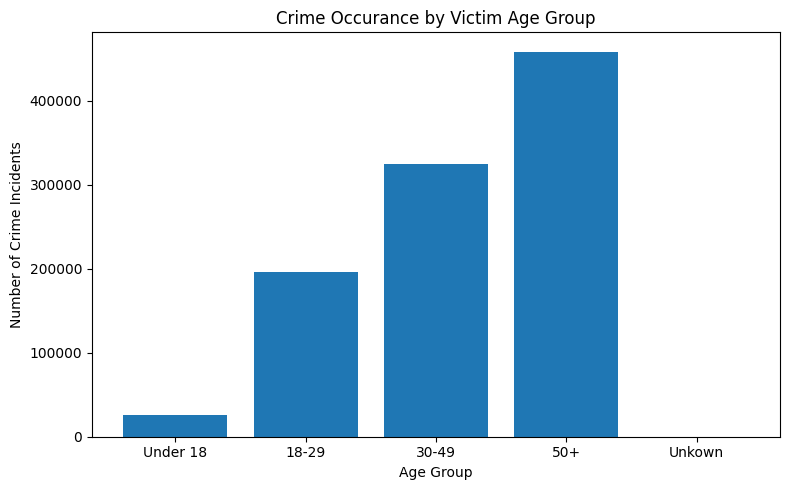

In [34]:
# Visual No. 1: Crime Count by Age Group:
age_counts = df['Age Group'].value_counts().reindex(age_order, fill_value = 0)
plt.figure(figsize = (8, 5))
plt.bar(age_counts.index, age_counts.values)
plt.title('Crime Occurance by Victim Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Crime Incidents')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

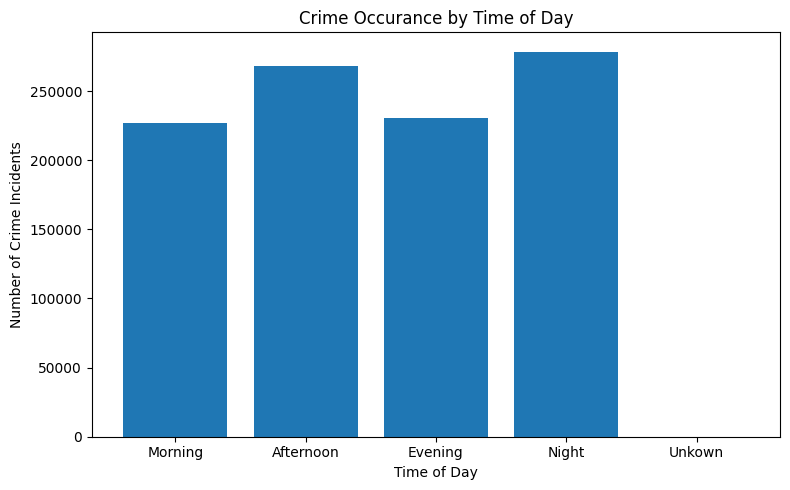

In [35]:
# Visual No. 2: Crime Count by Time of Day:
time_counts = df['Time of Day'].value_counts().reindex(time_order, fill_value = 0)
plt.figure(figsize = (8, 5))
plt.bar(time_counts.index, time_counts.values)
plt.title('Crime Occurance by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Crime Incidents')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

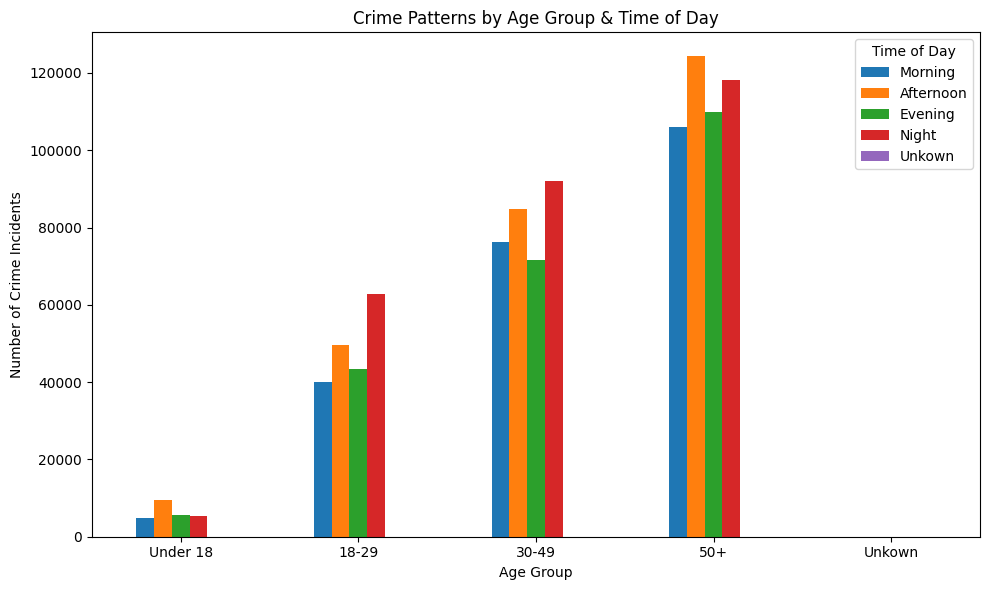

In [36]:
# Visual No.3: Crime count by both Age Group & Time of Day:
cross_tab = pd.crosstab(df['Age Group'], df['Time of Day'])
cross_tab = cross_tab.reindex(index = age_order, columns = time_order, fill_value = 0)
cross_tab.plot(kind = 'bar', figsize = (10, 6))
plt.title('Crime Patterns by Age Group & Time of Day')
plt.xlabel('Age Group')
plt.ylabel('Number of Crime Incidents')
plt.xticks(rotation = 0)
plt.legend(title = 'Time of Day')
plt.tight_layout()
plt.show()

In [38]:
# Interactive Visual: Crime Count by Age Group & Time of Day:
import plotly.express as px
# Creating a crosstab application for visual:
cross_tab = pd.crosstab(df['Age Group'], df['Time of Day'])
cross_tab = cross_tab.reindex(index = age_order, columns = time_order, fill_value = 0)
heatmap_data = cross_tab.reset_index().melt(
    id_vars = 'Age Group',
    var_name = 'Time of Day',
    value_name = 'Crime Count'
)
# Creating the interactive heatmap visualization:
fig = px.density_heatmap(
    heatmap_data,
    x = 'Time of Day',
    y = 'Age Group',
    z = 'Crime Count',
    title = 'Interactive Crime Patterns by Age Group & Time of Day',
    text_auto = True
)
fig.show()

# Code Attribution
Title: Project One Data Visualizer Portion

Professor(s): Fadi Alsaleem & Catherine Williams

Date: 27 March 2026

Modified By: Faith Wade

Description: This program is used to take code from the data wrangler & scientist, and use it to incorporate visualizations to create an answer for the primary and secondary research questions.
***
Title: Data Science Project One

Professor(s): Fadi Alsaleem & Catherine Williams

Date: 27 March 2026

Modified By: Faith Wade

Description: This program was modified to take the portion of code from the data wrangler (Silvia Rosario Betances) and data scientist (Hana Sijad) in order to create a Logistic Regression Model to take trained & tested data fit for the project and create three normal visualizations along with one interactive visualization.

Source(s):

https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html

https://plotly.com/python/2D-Histogram/